#### Tweak 1.2 — Global Average Pooling (GAP) Replacing Dense Layers

#### 1.1 Environment Check

In [1]:
import random
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

In [2]:
# reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
if device.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
VRAM            : 15.6 GB


#### 1.2 The Subset

In [3]:
def get_cifar10_subsets(batch_size=64):
    # Standard transformation
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load the full training and test datasets
    full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    full_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    # Take first 5k for training, first 1k for validation
    train_indices, _ = train_test_split(list(range(len(full_train))), train_size=5000, stratify=full_train.targets, random_state=SEED)
    train_subset = Subset(full_train, train_indices)
    test_indices, _ = train_test_split(list(range(len(full_test))), train_size=1000, stratify=full_test.targets, random_state=SEED)
    val_subset = Subset(full_test, test_indices)

    # Create DataLoaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, full_train.classes

In [4]:
train_loader, val_loader, classes = get_cifar10_subsets()

print(f'Training samples   : {len(train_loader.dataset)}')
print(f'Validation samples : {len(val_loader.dataset)}')
print(f'Classes            : {classes}')
print(f'Batch size         : {train_loader.batch_size}')

# quick sanity peek
imgs, labels = next(iter(train_loader))
print(f'Batch shape        : {imgs.shape}')  # [64, 3, 32, 32]

100%|██████████| 170M/170M [00:03<00:00, 42.8MB/s] 


Training samples   : 5000
Validation samples : 1000
Classes            : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batch size         : 64
Batch shape        : torch.Size([64, 3, 32, 32])


### 1.3 The Evaluation Suite

In [5]:
def count_parameters(model):
    """Return total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [6]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Compute average loss and accuracy on a dataloader."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                device, epochs=15):
    """
    Standard training loop. Returns history dict with per-epoch metrics.
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [],   'val_acc': []
    }
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, epochs + 1):
        # --- train ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total

        # --- validate ---
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # record
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # checkpoint best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f'Epoch {epoch:3d}/{epochs}  |  '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%')

    # restore best weights
    if best_weights:
        model.load_state_dict(best_weights)
    print(f'\nBest validation accuracy: {best_val_acc:.2f}%')
    return history

In [8]:
def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves side by side."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- loss ---
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   's-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- accuracy ---
    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   's-', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} — Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#### 2.1 Build Model 1.2 — GAP Replacing Dense Layers

In [9]:
class DeepCNN_GAP(nn.Module):
    """
    Model 1.2: DeepCNN with Global Average Pooling (GAP).
    Same conv backbone as Model 1.1, but dense classifier replaced by GAP.
    Architecture:
        Conv2d(3 -> 32, 3x3)  -> ReLU -> MaxPool(2)     # 32x32 -> 16x16
        Conv2d(32 -> 64, 3x3) -> ReLU -> MaxPool(2)     # 16x16 -> 8x8
        Conv2d(64 -> 128, 3x3) -> ReLU -> MaxPool(2)    # 8x8   -> 4x4
        AdaptiveAvgPool2d(1)                              # 4x4   -> 1x1 (GAP)
        Flatten -> FC(128 -> 10)
    """

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),    # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                                # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                                # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                                # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # (batch, 128, 4, 4) -> (batch, 128, 1, 1)
            nn.Flatten(),              # (batch, 128, 1, 1) -> (batch, 128)
            nn.Linear(128, 10),        # 128*10 + 10 = 1,290 params (vs ~527K in Model 1.1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
model = DeepCNN_GAP().to(device)
print(model)
print(f'\nTrainable parameters: {count_parameters(model):,}')

DeepCNN_GAP(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable parameters: 94,538


### 2.2 Train for 15 Epochs (Same Config as Baseline)

In [11]:
EPOCHS = 15 # complete pass through your entire training dataset
LR = 1e-3   # Learning Rate

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f'Optimizer : Adam (lr={LR})')
print(f'Loss fn   : CrossEntropyLoss')
print(f'Epochs    : {EPOCHS}')
print(f'Device    : {device}')
print('-' * 65)

start = time.time()
history = train_model(model, train_loader, val_loader, criterion,
                      optimizer, device, epochs=EPOCHS)
elapsed = time.time() - start
print(f'\nTraining time: {elapsed:.1f}s')

Optimizer : Adam (lr=0.001)
Loss fn   : CrossEntropyLoss
Epochs    : 15
Device    : cuda
-----------------------------------------------------------------
Epoch   1/15  |  Train Loss: 2.1221  Acc: 19.60%  |  Val Loss: 2.0174  Acc: 22.30%
Epoch   2/15  |  Train Loss: 1.9213  Acc: 27.56%  |  Val Loss: 1.8129  Acc: 31.50%
Epoch   3/15  |  Train Loss: 1.7850  Acc: 33.88%  |  Val Loss: 1.7340  Acc: 37.90%
Epoch   4/15  |  Train Loss: 1.7117  Acc: 35.84%  |  Val Loss: 1.6449  Acc: 40.30%
Epoch   5/15  |  Train Loss: 1.6237  Acc: 40.64%  |  Val Loss: 1.5762  Acc: 40.60%
Epoch   6/15  |  Train Loss: 1.5720  Acc: 42.48%  |  Val Loss: 1.5668  Acc: 42.00%
Epoch   7/15  |  Train Loss: 1.5210  Acc: 44.48%  |  Val Loss: 1.5900  Acc: 42.50%
Epoch   8/15  |  Train Loss: 1.5007  Acc: 45.74%  |  Val Loss: 1.5308  Acc: 42.70%
Epoch   9/15  |  Train Loss: 1.4561  Acc: 47.40%  |  Val Loss: 1.4541  Acc: 46.20%
Epoch  10/15  |  Train Loss: 1.4269  Acc: 48.30%  |  Val Loss: 1.4394  Acc: 47.00%
Epoch  11/15  |

#### 2.3 Visualize Training Curves

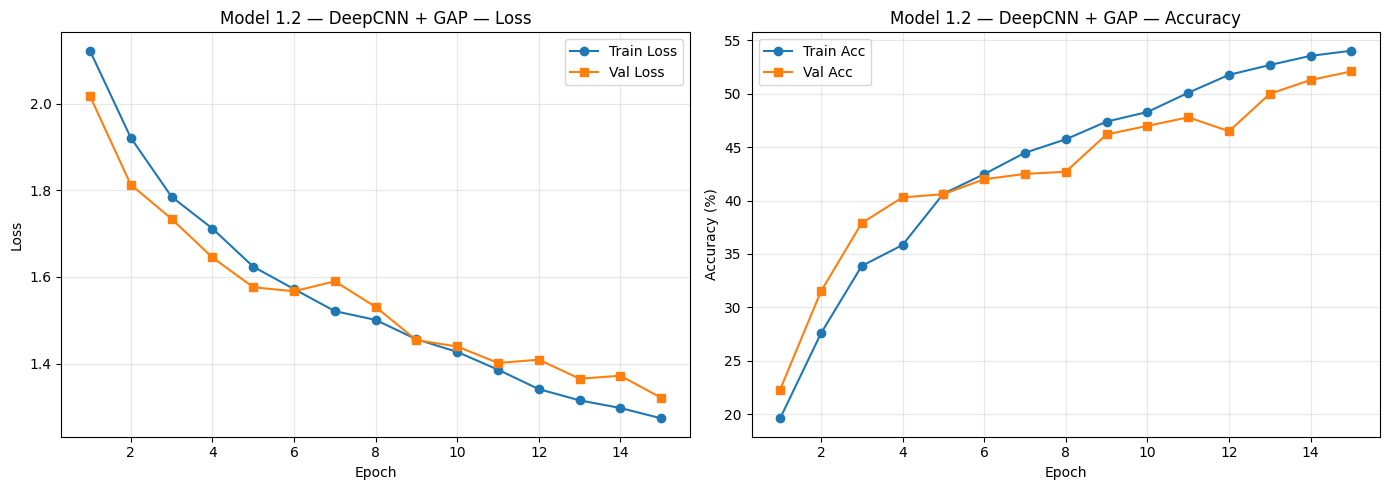

In [12]:
plot_history(history, title='Model 1.2 — DeepCNN + GAP')

### 2.4 Results Summary

In [13]:
final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]
peak_val_acc    = max(history['val_acc'])
gap             = final_train_acc - final_val_acc

print('=' * 50)
print('   MODEL 1.2 — RESULTS SUMMARY (GAP Replacing Dense)')
print('=' * 50)
print(f'  Parameters       : {count_parameters(model):,}')
print(f'  Final Train Acc  : {final_train_acc:.2f}%')
print(f'  Final Val Acc    : {final_val_acc:.2f}%')
print(f'  Peak Val Acc     : {peak_val_acc:.2f}%')
print(f'  Train-Val Gap    : {gap:+.2f}%')
print(f'  Final Train Loss : {history["train_loss"][-1]:.4f}')
print(f'  Final Val Loss   : {history["val_loss"][-1]:.4f}')
print(f'  Diagnosis      : Underfitting — GAP slashes params from 620K to 95K and kills overfitting, but single-conv blocks lack enough feature extraction power.')
print('=' * 50)

   MODEL 1.2 — RESULTS SUMMARY (GAP Replacing Dense)
  Parameters       : 94,538
  Final Train Acc  : 54.04%
  Final Val Acc    : 52.10%
  Peak Val Acc     : 52.10%
  Train-Val Gap    : +1.94%
  Final Train Loss : 1.2736
  Final Val Loss   : 1.3209
  Diagnosis      : Underfitting — GAP slashes params from 620K to 95K and kills overfitting, but single-conv blocks lack enough feature extraction power.
